In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['font.family'] = 'arial'

In [3]:
df_train = pd.read_csv("train_predictions_run_1.csv")
df_val = pd.read_csv("val_predictions_run_1.csv")

df_val = df_val.drop(62)

In [5]:
df_train.columns

Index(['composition', 'temperature(K)', 'true_seebeck_coefficient(μV/K)',
       'pred_seebeck_coefficient(μV/K)', 'true_electrical_conductivity(S/m)',
       'pred_electrical_conductivity(S/m)', 'true_thermal_conductivity(W/mK)',
       'pred_thermal_conductivity(W/mK)', 'true_ZT', 'pred_ZT',
       'true_power_factor(W/mK2)', 'pred_power_factor(W/mK2)'],
      dtype='object')

Text(0.5, 1.0, 'MTEncoder Predictions')

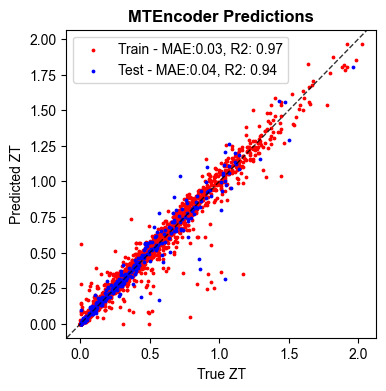

In [7]:
fig, ax = plt.subplots(figsize=(4,4))

ax.axline((0, 0), slope=1, color='k', linestyle='--', alpha=0.8, linewidth=1)

for df, split_name, color in zip(
    [df_train, df_val],
    ['Train', 'Test'],
    ['r', 'b']):

    mse = mean_squared_error(df['true_ZT'], df['pred_ZT'])
    mae = mean_absolute_error(df['true_ZT'], df['pred_ZT'])
    r2 = r2_score(df['true_ZT'], df['pred_ZT'])

    ax.scatter(df['true_ZT'], df['pred_ZT'],
               label=f'{split_name} - MAE:{mae:.2f}, R2: {r2:.2f}',
               c=color, s=3)

ax.legend()
ax.set_xlabel(f'True ZT',)
ax.set_ylabel(f'Predicted ZT',)
ax.set_title(f'MTEncoder Predictions', fontweight='bold')

In [6]:
estm_cleaned = pd.read_excel('estm_cleaned.xlsx')
estm_cleaned

,Formula,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),ZT,reference,Reason for deletion
0,BiSb(Se0.92Br0.08)3,300.0,-110.00,27766.0,0.6300,0.000336,0.159985,10.1002/adfm.201806558,NaN
1,BiSb(Se0.92Br0.08)3,400.0,-138.00,23883.0,0.5700,0.000455,0.319177,10.1002/adfm.201806558,NaN
2,BiSb(Se0.92Br0.08)3,500.0,-163.00,20850.0,0.5300,0.000554,0.522607,10.1002/adfm.201806558,NaN
3,BiSb(Se0.92Br0.08)3,600.0,-181.00,19000.0,0.5100,0.000622,0.732305,10.1002/adfm.201806558,NaN
4,BiSb(Se0.92Br0.08)3,700.0,-193.00,17925.0,0.5000,0.000668,0.940000,10.1002/adfm.201806558,NaN
...,...,...,...,...,...,...,...,...,...
4755,Ge9Sb2Te12,423.0,77.28,173636.0,2.8586,0.001037,0.153448,https://doi.org/10.1021/acsami.0c02155,NaN
4756,Ge9Sb2Te12,525.0,97.50,136364.0,2.7576,0.001296,0.246795,https://doi.org/10.1021/acsami.0c02155,NaN
4757,Ge9Sb2Te12,625.0,112.88,120000.0,2.8232,0.001529,0.338496,https://doi.org/10.1021/acsami.0c02155,NaN
4758,Ge9Sb2Te12,725.0,135.19,108182.0,2.5354,0.001977,0.565374,https://doi.org/10.1021/acsami.0c02155,NaN


In [8]:
estm_cleaned[estm_cleaned['Formula']=='Cu2Se']

,Formula,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),ZT,reference,Reason for deletion
95,Cu2Se,410.0,85.00,55023.0,0.8589,0.000398,0.189768,10.1002/adma.201302660,NaN
96,Cu2Se,300.0,92.00,99586.0,0.8800,0.000843,0.287351,10.1002/adma.201302660,NaN
97,Cu2Se,425.0,118.00,51060.0,0.8560,0.000711,0.352988,10.1002/adma.201302660,NaN
98,Cu2Se,350.0,101.48,87320.0,0.8000,0.000899,0.393417,10.1002/adma.201302660,NaN
99,Cu2Se,450.0,126.00,47255.0,0.8560,0.000750,0.394392,10.1002/adma.201302660,NaN
100,Cu2Se,359.0,104.40,82534.0,0.7300,0.000900,0.442390,10.1002/adma.201302660,NaN
101,Cu2Se,365.0,107.40,76750.0,0.6700,0.000885,0.482286,10.1002/adma.201302660,NaN
102,Cu2Se,375.0,114.57,64785.0,0.5400,0.000850,0.590546,10.1002/adma.201302660,NaN
103,Cu2Se,385.0,127.40,52850.0,0.3835,0.000858,0.861151,10.1002/adma.201302660,NaN
104,Cu2Se,400.0,166.70,40986.0,0.2000,0.001139,2.277911,10.1002/adma.201302660,NaN


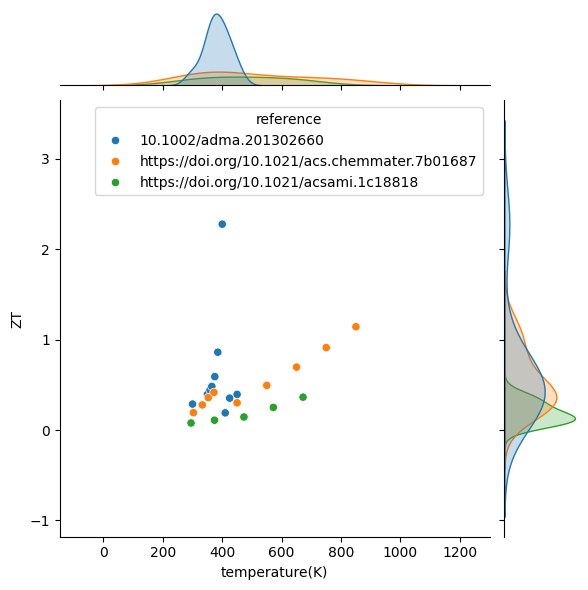

In [14]:
import seaborn as sb

sb.jointplot(
    data=estm_cleaned[estm_cleaned['Formula']=='Cu2Se'],
    x='temperature(K)',
    y='ZT',
    hue='reference',
)